In [17]:
import pandas as pd
import numpy as np
import yfinance as yf
import importlib
import requests
from io import StringIO

# Funciones auxiliares
import auxfun
importlib.reload(auxfun)

<module 'auxfun' from 'c:\\Users\\Deportivo Estadio\\Desktop\\Master Quant\\Gestión de activos\\Trabajo gestión cuantitativa\\Trabajo_gestion_cuantitativa\\Trabajo_gestion_cuantitativa\\Monitoring\\auxfun.py'>

In [18]:
df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
cash = auxfun.calcular_cash_diario(df)
todas_fechas = pd.date_range(start=df['fecha'].min(), end=pd.Timestamp.today(), freq="D")
stoxx_data = yf.download("^STOXX50E", start=todas_fechas.min(), end=todas_fechas.max(), auto_adjust=True, progress=False)["Close"].squeeze()
stoxx_data = stoxx_data.reindex(todas_fechas).ffill()
serie_con_costes = auxfun.valor_cartera_diario(df).reindex(todas_fechas).ffill()

# Normalizamos a 10 millones para comparar con la cartera
stoxx_norm = stoxx_data / stoxx_data.iloc[0] * 10*1e6

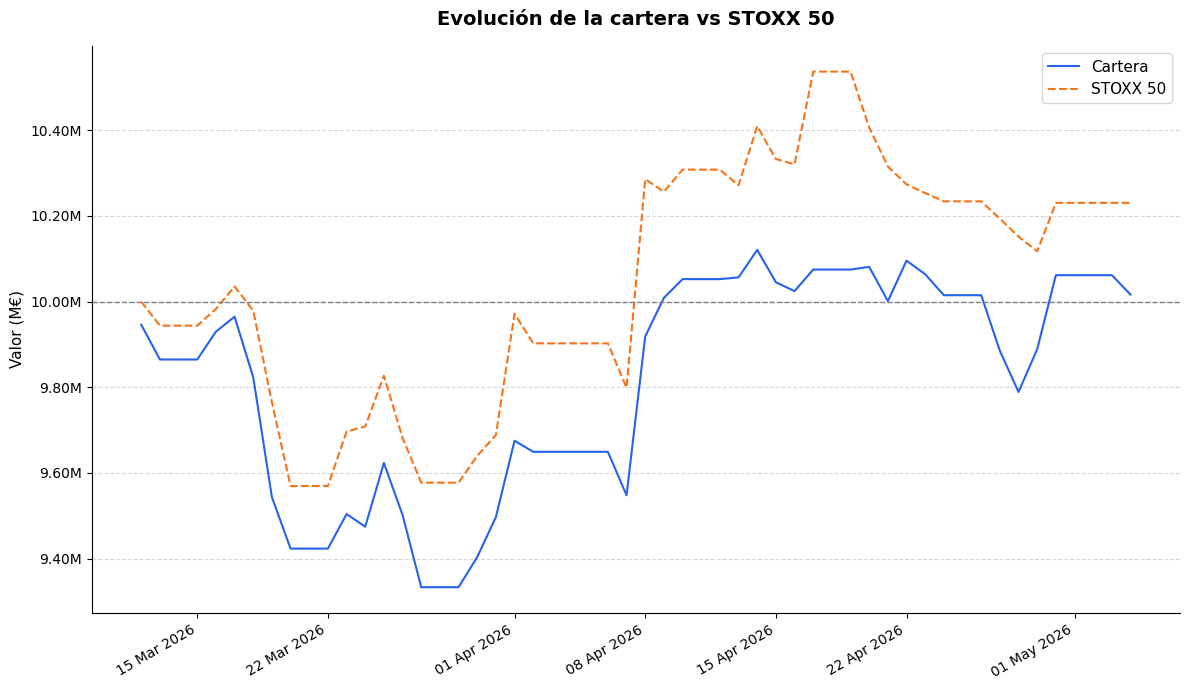

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(12, 7))

df_plot = pd.DataFrame({
    "Cartera": serie_con_costes / 1e6,
    "STOXX50": stoxx_norm / 1e6
})

ax.plot(df_plot.index, df_plot["Cartera"], label="Cartera", color="#2563EB", linewidth=1.5)
ax.plot(df_plot.index, df_plot["STOXX50"], label="STOXX 50", color="#F97316", linewidth=1.5, linestyle="--")
ax.axhline(y=10, color="gray", linestyle="--", linewidth=1)

ax.set_title("Evolución de la cartera vs STOXX 50", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Valor (M€)", fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}M"))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b %Y"))
plt.xticks(rotation=30, ha="right")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
serie_con_costes

2026-03-12    9.945908e+06
2026-03-13    9.864855e+06
2026-03-14    9.864855e+06
2026-03-15    9.864855e+06
2026-03-16    9.929798e+06
2026-03-17    9.964868e+06
2026-03-18    9.823423e+06
2026-03-19    9.543405e+06
2026-03-20    9.423150e+06
2026-03-21    9.423150e+06
2026-03-22    9.423150e+06
2026-03-23    9.503831e+06
2026-03-24    9.474390e+06
2026-03-25    9.623265e+06
2026-03-26    9.501746e+06
2026-03-27    9.333069e+06
2026-03-28    9.333069e+06
2026-03-29    9.333069e+06
2026-03-30    9.403432e+06
2026-03-31    9.496964e+06
2026-04-01    9.675131e+06
2026-04-02    9.649239e+06
2026-04-03    9.649239e+06
2026-04-04    9.649239e+06
2026-04-05    9.649239e+06
2026-04-06    9.649239e+06
2026-04-07    9.547680e+06
2026-04-08    9.918752e+06
2026-04-09    1.000871e+07
2026-04-10    1.005254e+07
2026-04-11    1.005254e+07
2026-04-12    1.005254e+07
2026-04-13    1.005662e+07
2026-04-14    1.012079e+07
2026-04-15    1.004518e+07
2026-04-16    1.002455e+07
2026-04-17    1.007491e+07
2

In [21]:
def get_eurostoxx50_tickers():
    url = 'https://en.wikipedia.org/wiki/EURO_STOXX_50'
    headers = {"User-Agent": "Mozilla/5.0 ..."}
    response = requests.get(url, headers=headers, timeout=20)
    response.raise_for_status()

    tables = pd.read_html(StringIO(response.text), flavor='bs4')
    df = next(t for t in tables if 'Ticker' in t.columns)
    return df['Ticker'].tolist()

universo_tickers = get_eurostoxx50_tickers()

df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
resumen = auxfun.resumen_nav_desagregacion(df, universo_tickers)
display(resumen)

Fecha valoración           2026-05-04
NAV                   10016932.435093
NAV normalizado              1.001693
Rentabilidad NAV             0.001693
Resultado NAV (€)        16932.435093
Efecto mercado (€)       28468.736971
Alpha (€)               -11536.301879
Ef. selección (€)       106239.659082
Ef. pesos (€)           -86089.475071
Costes (€)               -31686.48589
Check NAV (€)                     0.0
dtype: object

In [22]:
0.007703*10000000

77030.0

In [23]:
import sys
sys.path.append("../")  # o la ruta donde esté auxiliary_functions.py
from auxiliary_functions import build_metrics_table

metrics = build_metrics_table({
    "Cartera": serie_con_costes,
    # "Cartera sin costes": serie_sin_costes,
    "STOXX50": stoxx_norm
}, periods_per_year=365)  # usamos 365 porque la serie es diaria con todos los días del calendario

display(metrics.T)

,Cartera,STOXX50
Rentabilidad total,0.007101,0.023069
Rentabilidad anualizada,0.049938,0.170071
Volatilidad anualizada,0.193622,0.210598
Sharpe,0.346275,0.847873
Sortino,0.534922,1.607131
Max Drawdown,-0.063403,-0.046448
Calmar,0.787636,3.661545
Win rate,0.320755,0.245283
Mejor periodo,0.038865,0.049732
Peor periodo,-0.028505,-0.021444


In [24]:
df = pd.read_csv("../mi_cartera/historial_operaciones.csv", parse_dates=["fecha"])
tabla_semanal = auxfun.analisis_todas_semanas(df, universo_tickers)